In [ ]:
#libraries required
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics
from sklearn import linear_model
from sklearn import ensemble
from sklearn import tree
from sklearn import svm
import xgboost

In [ ]:
data = pd.read_csv("/content/WeatherAUS.csv - Dataset.csv")

In [ ]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,@
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,0.0
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,NaN
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,NaN
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,NaN
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,NaN
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,NaN
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,NaN
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
data.shape

(145460, 24)

In [ ]:
data.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


<Axes: >

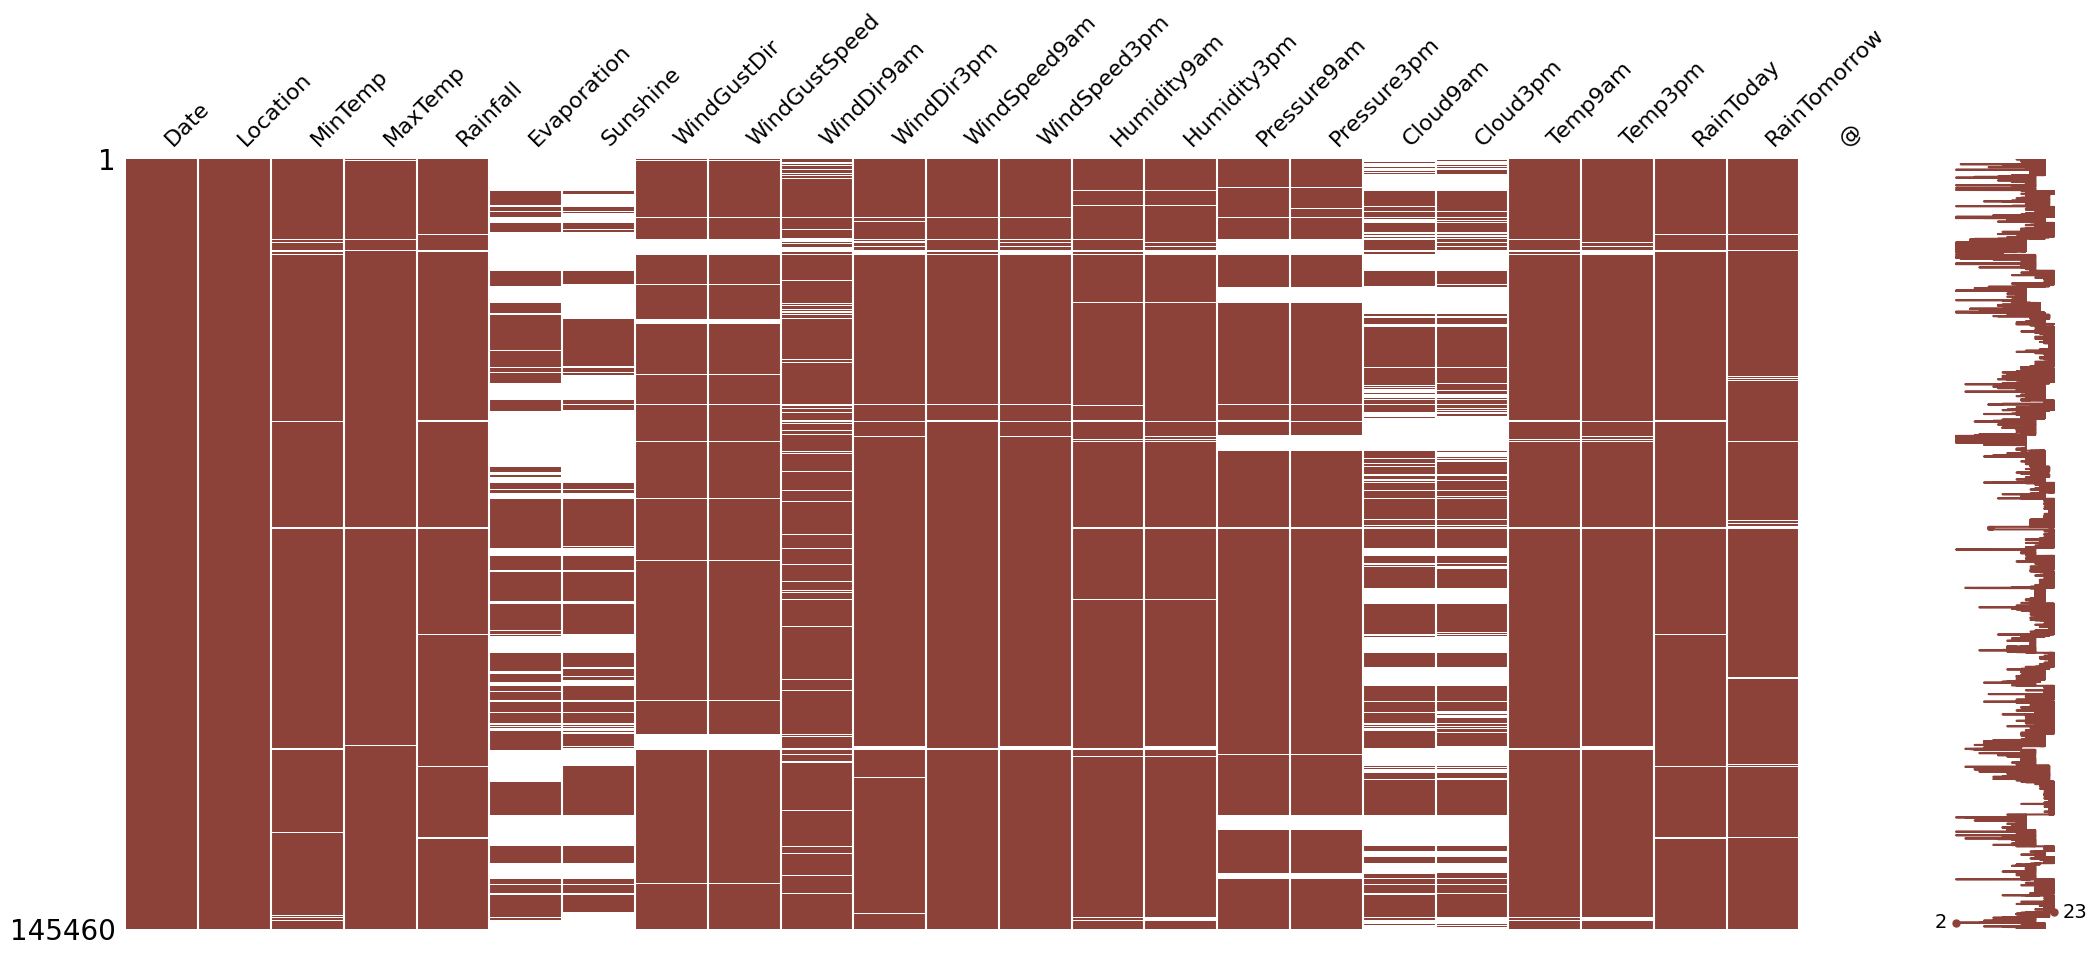

In [ ]:
import missingno as msno
msno.matrix(data,color=(0.55, 0.255,0.225), fontsize=16)

In [ ]:
# removing columns with more than 20% missing values and segregating cat and num variables
data_cat = data[['RainToday','WindGustDir','WindDir9am','WindDir3pm']]
data.drop(columns=['Evaporation','Sunshine','Cloud9am','Cloud3pm'],axis=1,inplace=True)
data.drop(columns=['RainToday','WindGustDir','WindDir9am','WindDir3pm'],axis=1,inplace=True)

In [ ]:
# filling the missing data of numeric variables with mean
data['MinTemp'].fillna(data['MinTemp'].mean(),inplace=True)
data['MaxTemp'].fillna(data['MaxTemp'].mean(),inplace=True)
data['Rainfall'].fillna(data['Rainfall'].mean(),inplace=True)
data['WindGustSpeed'].fillna(data['WindGustSpeed'].mean(),inplace=True)
data['WindSpeed9am'].fillna(data['WindSpeed9am'].mean(),inplace=True)
data['WindSpeed3pm'].fillna(data['WindSpeed3pm'].mean(),inplace=True)
data['Humidity9am'].fillna(data['Humidity9am'].mean(),inplace=True)
data['Humidity3pm'].fillna(data['Humidity3pm'].mean(),inplace=True)
data['Pressure9am'].fillna(data['Pressure9am'].mean(),inplace=True)
data['Pressure3pm'].fillna(data['Pressure3pm'].mean(),inplace=True)
data['Temp9am'].fillna(data['Temp9am'].mean(),inplace=True)
data['Temp3pm'].fillna(data['Temp3pm'].mean(),inplace=True)

/tmp/ipython-input-2431055431.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MinTemp'].fillna(data['MinTemp'].mean(),inplace=True)
/tmp/ipython-input-2431055431.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
# loading the names of categorical columns
cat_names = data_cat.columns

In [ ]:
# initializing the simple imputer for missing categorical values
import numpy as np
from sklearn.impute import SimpleImputer

imp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [ ]:
# fitting and transforming the missing data
data_cat = imp_mode.fit_transform(data_cat)

In [ ]:
# converting array to dataframe
data_cat = pd.DataFrame(data_cat, columns=cat_names)

In [ ]:
# concatenating the categorical and numeric data
data = pd.concat([data, data_cat], axis=1)

In [ ]:
data.corr(numeric_only=True)


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,@
MinTemp,1.000000,0.733400,0.102706,0.172553,0.173404,0.173058,-0.230970,0.005995,-0.423584,-0.433147,0.897692,0.699211,NaN
MaxTemp,0.733400,1.000000,-0.074040,0.065895,0.014294,0.049717,-0.497927,-0.498760,-0.308309,-0.396622,0.879170,0.968713,NaN
Rainfall,0.102706,-0.074040,1.000000,0.126446,0.085925,0.056527,0.221380,0.248905,-0.159055,-0.119541,0.011069,-0.077684,NaN
WindGustSpeed,0.172553,0.065895,0.126446,1.000000,0.577319,0.657243,-0.207964,-0.025355,-0.425760,-0.383938,0.145904,0.031884,NaN
WindSpeed9am,0.173404,0.014294,0.085925,0.577319,1.000000,0.512427,-0.268271,-0.030887,-0.215339,-0.165388,0.127592,0.004476,NaN
WindSpeed3pm,0.173058,0.049717,0.056527,0.657243,0.512427,1.000000,-0.143458,0.016275,-0.277604,-0.239659,0.161060,0.027587,NaN
Humidity9am,-0.230970,-0.497927,0.221380,-0.207964,-0.268271,-0.143458,1.000000,0.659072,0.131503,0.176009,-0.469641,-0.490709,NaN
Humidity3pm,0.005995,-0.498760,0.248905,-0.025355,-0.030887,0.016275,0.659072,1.000000,-0.025848,0.048695,-0.216964,-0.555608,NaN
Pressure9am,-0.423584,-0.308309,-0.159055,-0.425760,-0.215339,-0.277604,0.131503,-0.025848,1.000000,0.959662,-0.397131,-0.265532,NaN
Pressure3pm,-0.433147,-0.396622,-0.119541,-0.383938,-0.165388,-0.239659,0.176009,0.048695,0.959662,1.000000,-0.441459,-0.360707,NaN


In [ ]:
cor = data.corr(numeric_only=True)

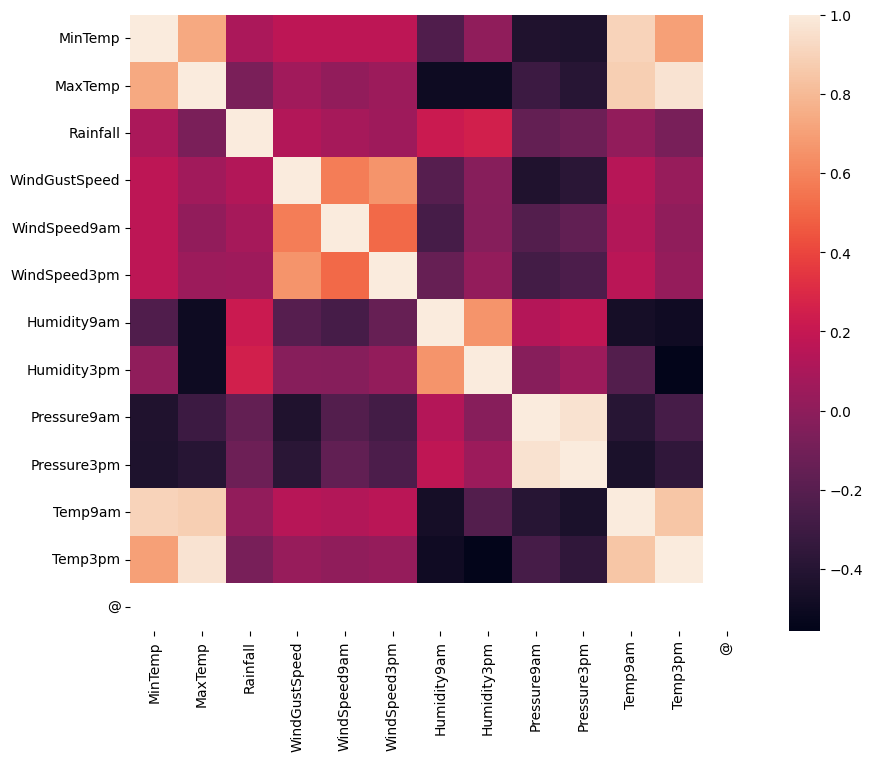

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cor,
            xticklabels=cor.columns.values,
            yticklabels=cor.columns.values)

plt.show()

In [ ]:
cols = ['MinTemp','MaxTemp','Rainfall',
        'Humidity9am','Humidity3pm',
        'Temp9am','Temp3pm',
        'RainTomorrow']

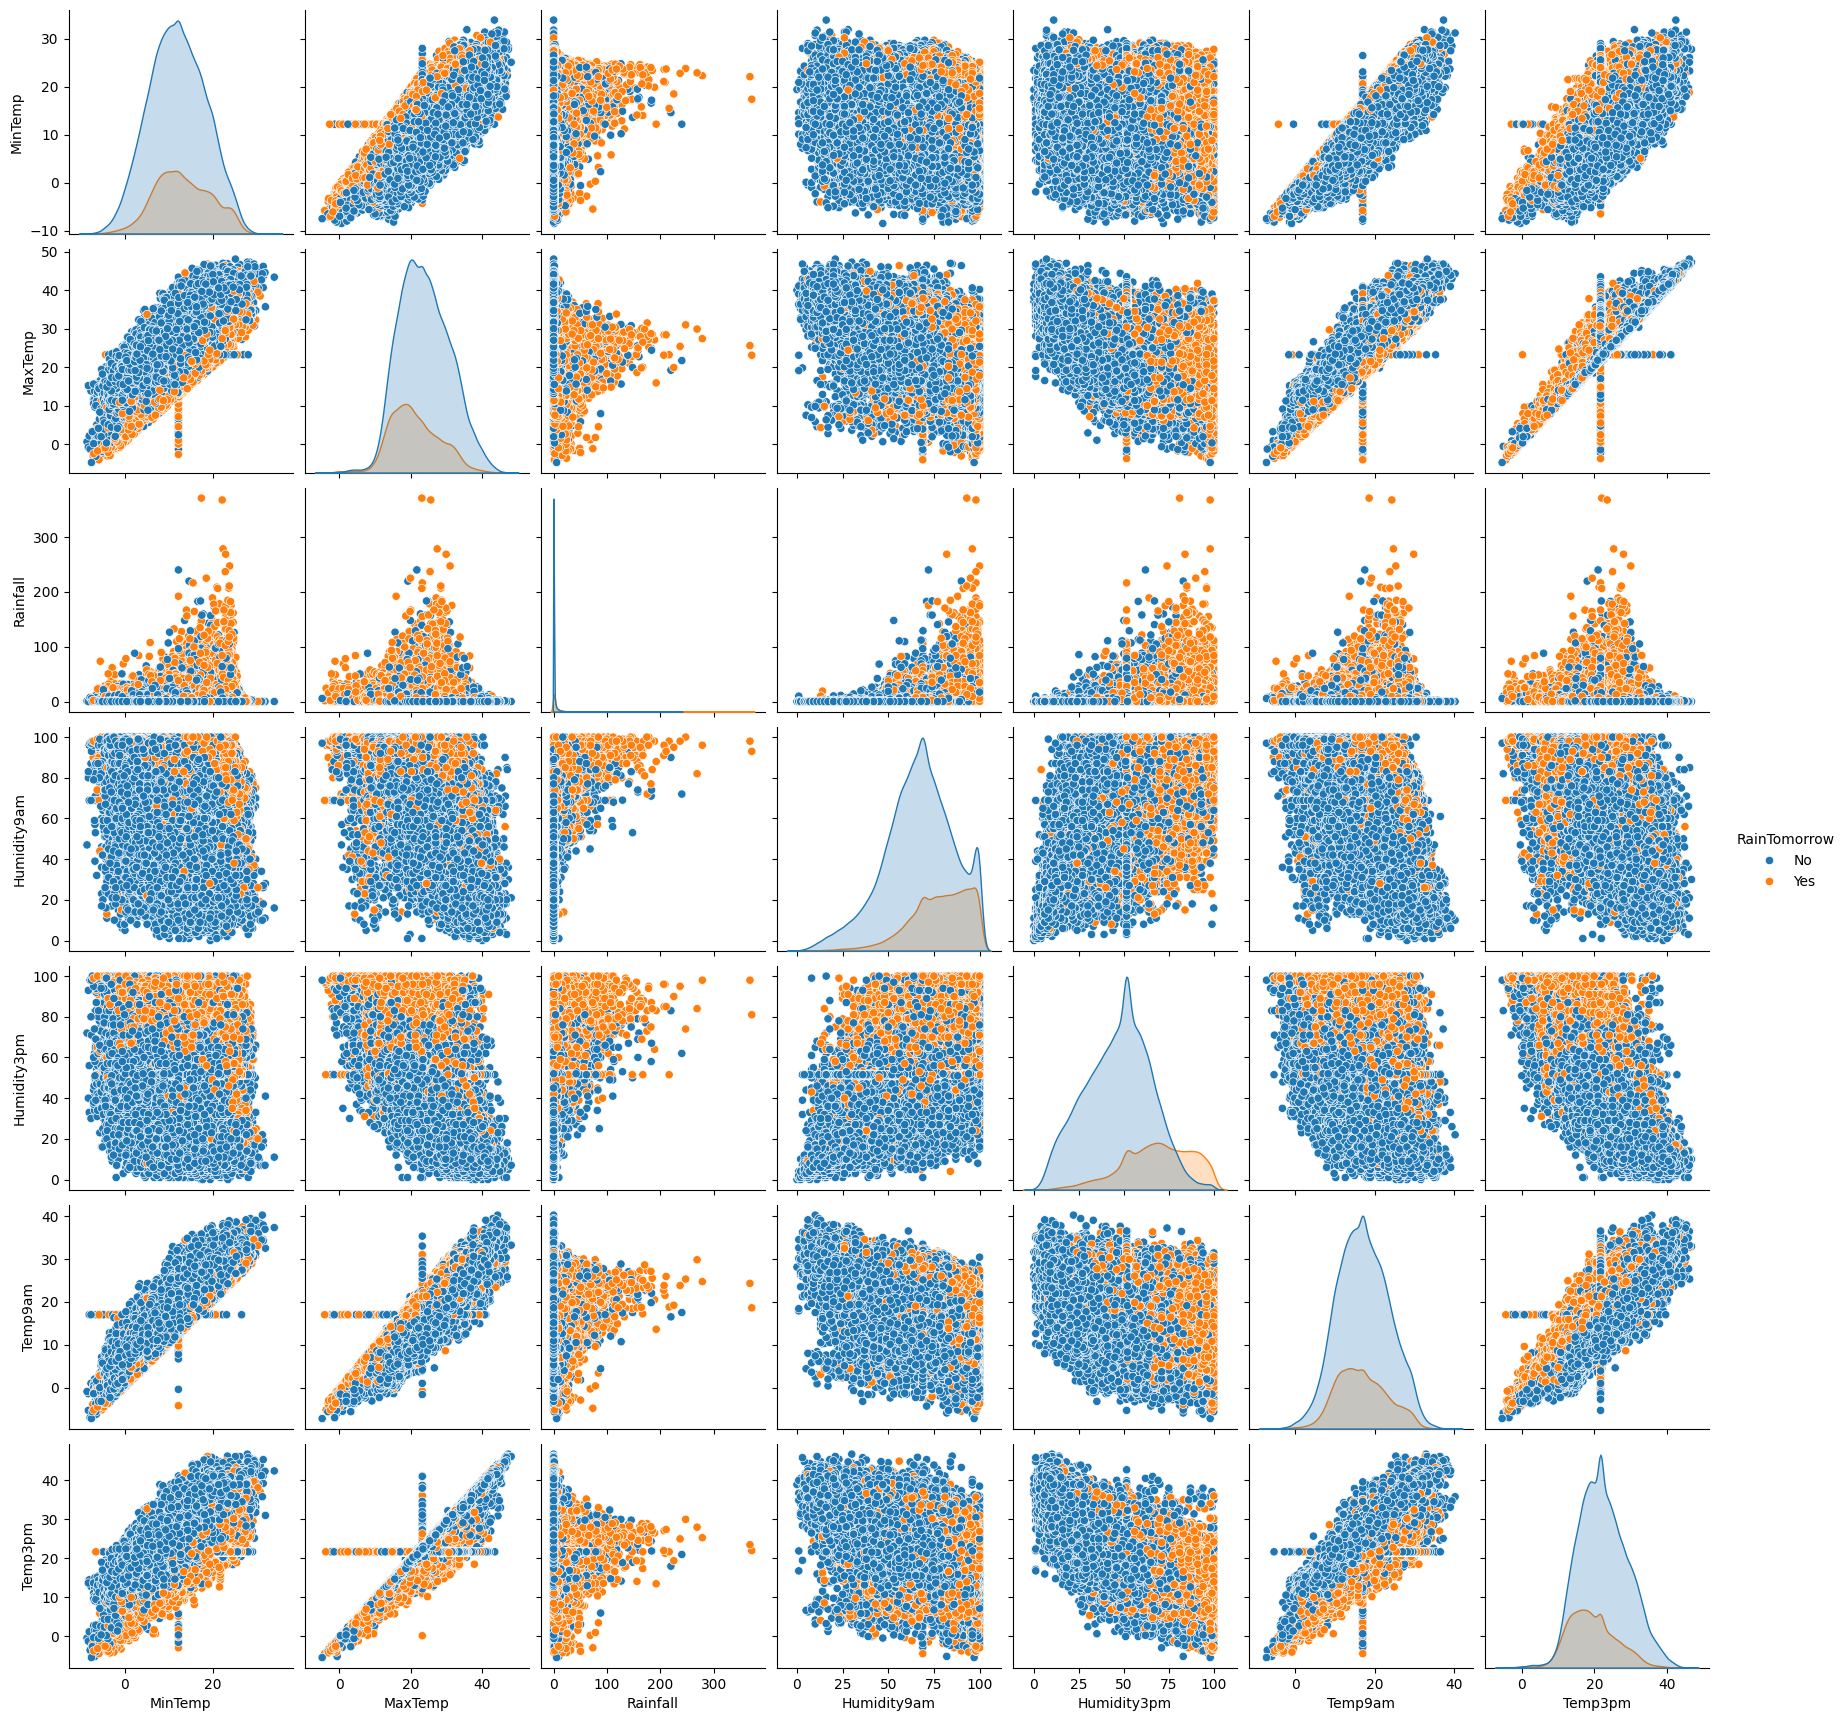

In [ ]:
sns.pairplot(data[cols],
             hue='RainTomorrow',
             diag_kind='kde')

<Axes: >

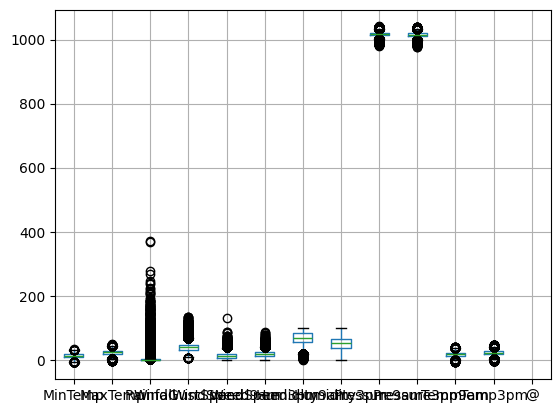

In [ ]:
data.boxplot()

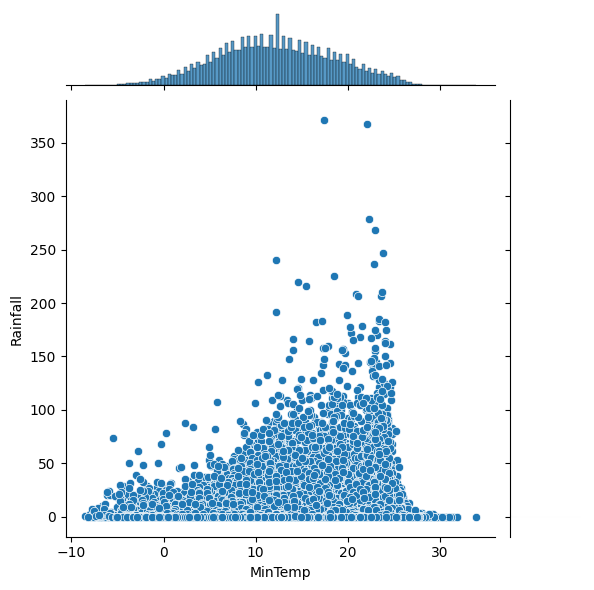

In [ ]:
sns.jointplot(x='MinTemp',
              y='Rainfall',
              data=data)

plt.show()

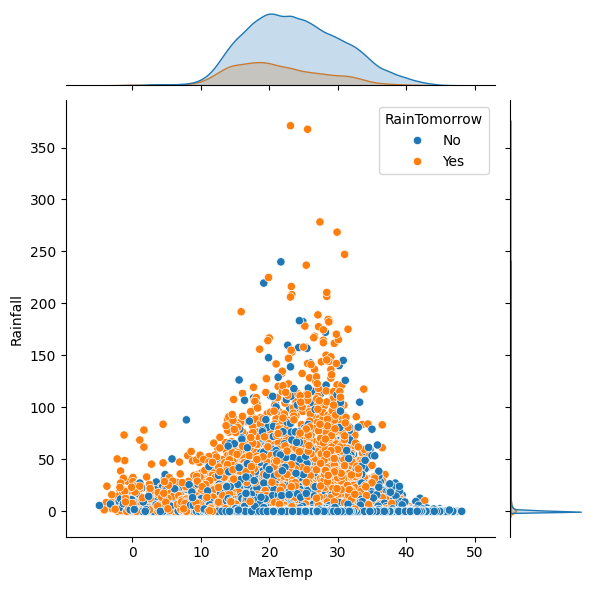

In [ ]:
sns.jointplot(x='MaxTemp',
              y='Rainfall',
              data=data,
              hue='RainTomorrow')

plt.show()


<Axes: xlabel='RainTomorrow', ylabel='Count'>

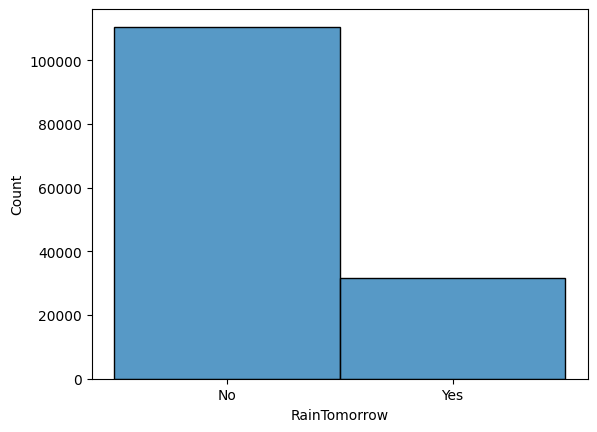

In [ ]:
sns.histplot(data['RainTomorrow'])

<Axes: xlabel='MaxTemp', ylabel='Rainfall'>

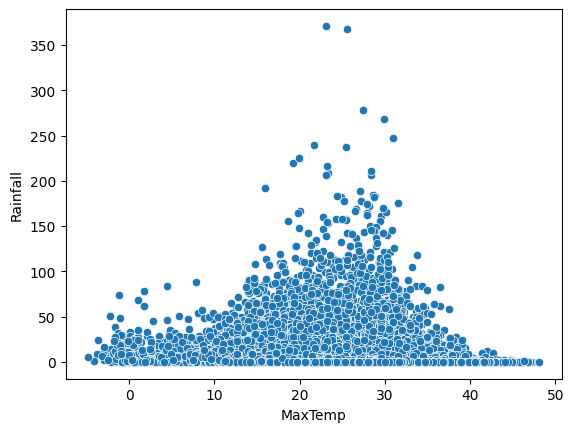

In [ ]:
sns.scatterplot(x='MaxTemp', y='Rainfall', data=data)

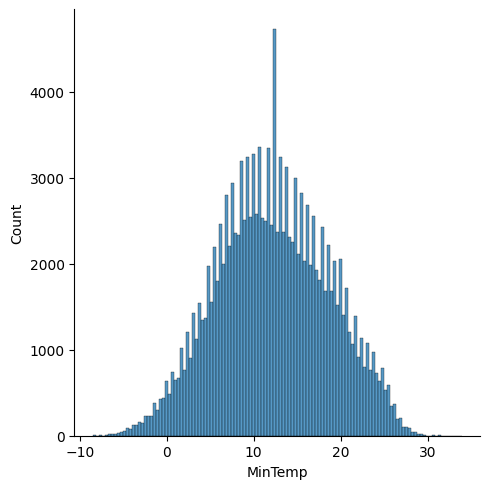

In [ ]:
sns.displot(data['MinTemp'])

In [ ]:
data = data.dropna(subset=['RainTomorrow'])


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['RainTomorrow'] = le.fit_transform(data['RainTomorrow'])



/tmp/ipython-input-1825036019.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RainTomorrow'] = le.fit_transform(data['RainTomorrow'])


In [ ]:
# splitting x and y values
y = data['RainTomorrow']
x = data.drop('RainTomorrow', axis=1)



In [ ]:
x = x.select_dtypes(include=['int64','float64'])

In [ ]:
x.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
x= x.fillna(x.mean())

In [ ]:
print("Remaining NaN values:", x.isnull().sum().sum())

Remaining NaN values: 142207


In [ ]:
names = x.columns  # loading the names of the x_features


In [ ]:
names


Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', '@'],
      dtype='object')

In [ ]:
sc = StandardScaler()  # initializing the standardscaler


In [ ]:
x = sc.fit_transform(x)  # fitting and transforming the data into standard


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
x = pd.DataFrame(x, columns=names)  # converting back to dataframe


In [ ]:
from sklearn import model_selection

In [ ]:
x_train,x_test,y_train,y_test = model_selection.train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
# Models initialization of the models
import xgboost
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
XGBoost = xgboost.XGBClassifier()
Rand_forest = RandomForestClassifier()
SVM = SVC()
Dtree = DecisionTreeClassifier()
GBM = GradientBoostingClassifier()
KNN = KNeighborsClassifier()
log = LogisticRegression()

In [ ]:
# fitting the model
XGBoost.fit(x_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
x_train_cleaned = x_train.drop(columns=['@'])

In [ ]:
Rand_forest.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
SVM.fit(x_train_cleaned, y_train)

In [ ]:
Dtree.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:

GBM.fit(x_train_cleaned_gbm, y_train)

GradientBoostingClassifier()

In [ ]:
x_train_cleaned_knn = x_train.drop(columns=['@'])
KNN.fit(x_train_cleaned_knn, y_train)

KNeighborsClassifier()

In [ ]:
x_train_cleaned_log = x_train.drop(columns=['@'])
log.fit(x_train_cleaned_log, y_train)

LogisticRegression()

In [ ]:
x_test_cleaned = x_test.drop(columns=['@'])

p_xgb_test = XGBoost.predict(x_test)
p_rf_test = Rand_forest.predict(x_test)
p_svm_test = SVM.predict(x_test_cleaned)
p_dt_test = Dtree.predict(x_test)
p_gbm_test = GBM.predict(x_test_cleaned)
p_knn_test = KNN.predict(x_test_cleaned)
p_log_test = log.predict(x_test_cleaned)

print("Predictions made successfully for all models on the test data.")

Predictions made successfully for all models on the test data.


In [ ]:
# predicting the train values
p1 = XGBoost.predict(x_train)
p2 = Rand_forest.predict(x_train)
p3 = SVM.predict(x_train_cleaned)
p4 = Dtree.predict(x_train)
p5 = GBM.predict(x_train_cleaned_gbm)
p6 = KNN.predict(x_train_cleaned_knn)
p7 = log.predict(x_train_cleaned_log)

# checking the accuracy score (training data)
from sklearn import metrics
print("XGBoost:", metrics.accuracy_score(y_train, p1))
print("Random Forest:", metrics.accuracy_score(y_train, p2))
print("SVM:", metrics.accuracy_score(y_train, p3))
print("Decision Tree:", metrics.accuracy_score(y_train, p4))
print("GBM:", metrics.accuracy_score(y_train, p5))
print("KNN:", metrics.accuracy_score(y_train, p6))
print("Logistic Regression:", metrics.accuracy_score(y_train, p7))


XGBoost: 0.8764206917769085
Random Forest: 0.9999033094536984
SVM: 0.850041752735903
Decision Tree: 0.9999472597020174
GBM: 0.8471498263965191
KNN: 0.8749263833340658
Logistic Regression: 0.8379290642992133


In [140]:
print("xgboost:",metrics.accuracy_score(y_test,p_xgb_test))
print("Rand_forest:",metrics.accuracy_score(y_test,p_rf_test))
print("svm:",metrics.accuracy_score(y_test,p_svm_test))
print("Dtree:",metrics.accuracy_score(y_test,p_dt_test))
print("GBM:",metrics.accuracy_score(y_test,p_gbm_test))
print("log:",metrics.accuracy_score(y_test,p_log_test))

xgboost: 0.8503972997679488
Rand_forest: 0.8522255818859433
svm: 0.8495886365234512
Dtree: 0.7771605372336685
GBM: 0.8468813726179594
log: 0.8405527037479783


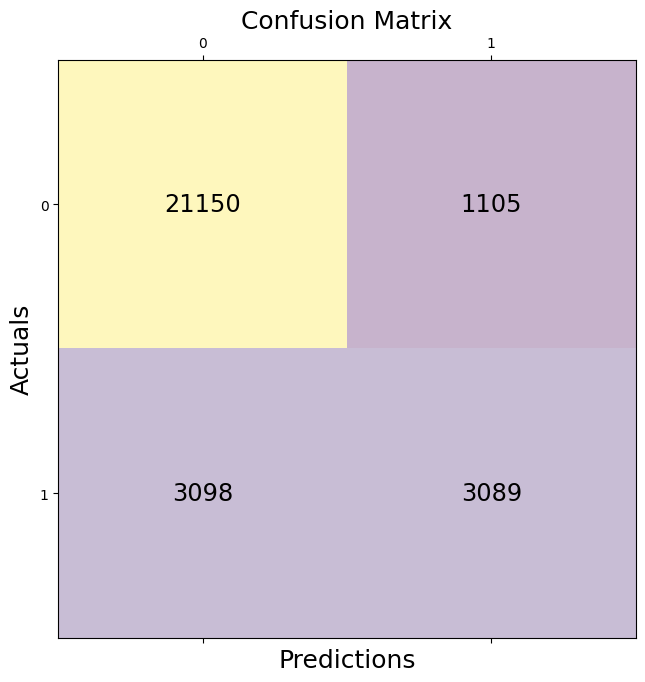

In [142]:
conf_matrix = metrics.confusion_matrix(y_test,p_rf_test)

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.matshow(conf_matrix, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i,s=conf_matrix[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Confusion Matrix', fontsize=18)
plt.show()

In [144]:
print(conf_matrix)
print("Accuracy:", best_model['Accuracy'])
print("Precision:", best_model['Precision'])
print("Recall:", best_model['Recall'])
print("F1-score:", best_model['F1-Score'])

[[21150  1105]
 [ 3098  3089]]
Accuracy: 0.8522255818859433
Precision: 0.7365283738674296
Recall: 0.4992726684984645
F1-score: 0.5951257104325209


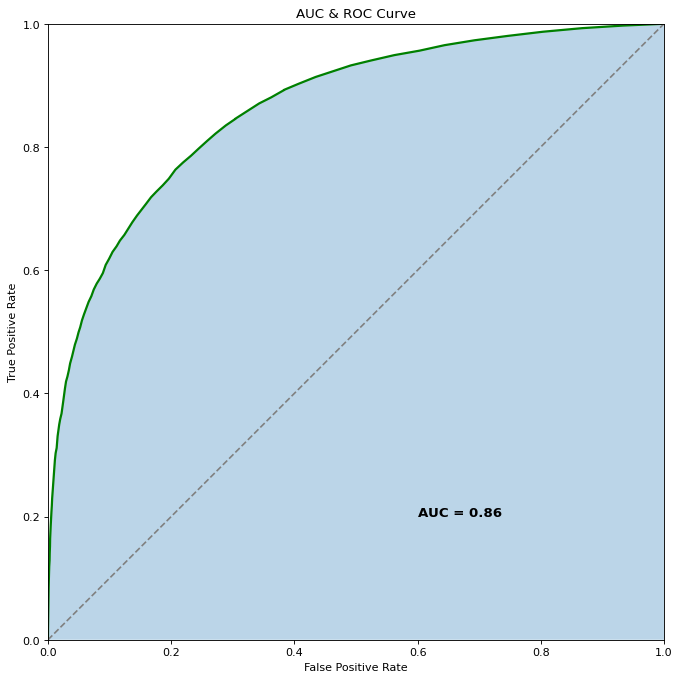

In [149]:
model = Rand_forest # Assign the trained RandomForestClassifier object
y_prob = model.predict_proba(x_test)[:, 1] # Use x_test instead of X_test

auc = metrics.roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)

plt.figure(figsize=(12, 10), dpi=80)
plt.axis('scaled')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.title("AUC & ROC Curve")

plt.plot(fpr, tpr, color='green', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # diagonal line

plt.fill_between(fpr, tpr, alpha=0.3)
plt.text(0.6, 0.2, f"AUC = {auc:.2f}", fontsize=12, weight='bold')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [150]:
import pickle


In [151]:
pickle.dump(model, open('rainfall.pkl', 'wb'))   # model
pickle.dump(le, open('encoder.pkl', 'wb'))       # encoder saving
pickle.dump(imp_mode, open('impter.pkl', 'wb'))  # imputer saving
pickle.dump(sc, open('scale.pkl', 'wb'))         # scaling the data
